# Question 1


Using the Adult Census Income Dataset (UCI Machine Learning Repository), design and implement a complete machine learning pipeline to analyze and demonstrate GPU-accelerated binning and model training.

### Objectives:
- Load and preprocess the dataset
- Identify feature types (Continuous, Discrete, Categorical, Binary)
- Demonstrate GPU-based histogram binning using cuDF and CuPy
- Compare GPU histograms with CPU (NumPy)
- Perform quantile binning on GPU
- Train and compare CPU vs GPU model performance
- Implement XGBoost with GPU acceleration (`tree_method='gpu_hist'`) and compare with cuML

In [3]:
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
urllib.request.urlretrieve(url, "adult.csv")

('adult.csv', <http.client.HTTPMessage at 0x785d70cb7140>)

fatal: destination path 'rapidsai-csp-utils' already exists and is not an empty directory.
Installing RAPIDS remaining 26.02 libraries
Using Python 3.12.13 environment at: /usr
Checked 9 packages in 188ms

        ***********************************************************************
        The pip install of RAPIDS is complete.

        Please do not run any further installation from the conda based installation methods, as they may cause issues!

        Please ensure that you're pulling from the git repo to remain updated with the latest working install scripts.

        Troubleshooting:
            - If there is an installation failure, please check back on RAPIDSAI owned templates/notebooks to see how to update your personal files.
            - If an installation failure persists when using the latest script, please make an issue on https://github.com/rapidsai-community/rapidsai-csp-utils
        ***********************************************************************
        


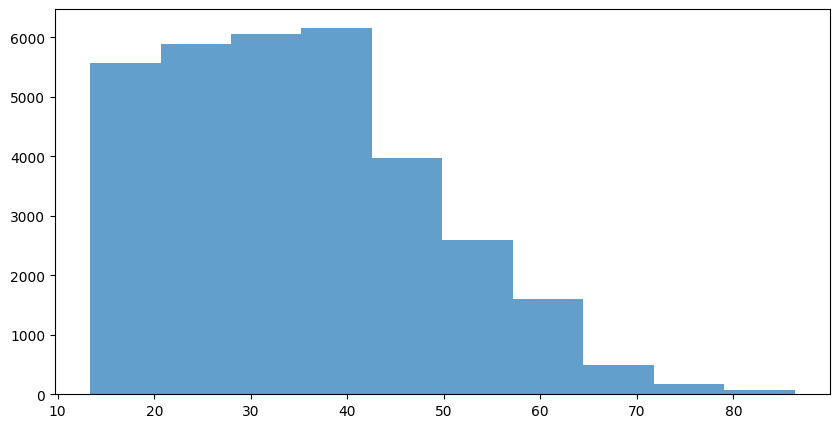

GPU RF Acc: 0.8621 | Time: 0.9583s
CPU RF Acc: 0.8574 | Time: 2.8810s
XGB Acc   : 0.8726 | Time: 0.2644s
Speedup (GPU/CPU RF): 3.01x


In [4]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

import cudf
import cupy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from cuml.ensemble import RandomForestClassifier as RF_gpu
from sklearn.ensemble import RandomForestClassifier as RF_cpu


cols = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

df = cudf.read_csv("adult.csv", names=cols, skipinitialspace=True, na_values=["?"])
df = df.dropna()

num_cols = ["age", "fnlwgt", "capital-gain", "capital-loss", "hours-per-week"]
cat_cols = ["workclass", "education", "marital-status", "occupation",
            "relationship", "race", "sex", "native-country"]

for c in num_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = cudf.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=num_cols)

for c in num_cols:
    df[c] = df[c].astype('float32')


col_bin = "age"
arr_gpu = df[col_bin].to_cupy()

t0 = time.time()
cnt_gpu, edge_gpu = cp.histogram(arr_gpu, bins=10)
t_gpu = time.time() - t0

pdf = df.to_pandas()

t0 = time.time()
cnt_cpu, edge_cpu = np.histogram(pdf[col_bin], bins=10)
t_cpu = time.time() - t0


plt.figure(figsize=(10,5))
plt.bar(edge_gpu[:-1].get(), cnt_gpu.get(),
        width=np.diff(edge_gpu.get()),
        alpha=0.7)
plt.show()


q = cp.linspace(0, 1, 6)
edges_q = cp.quantile(df['age'].to_cupy(), q)

bins_np = cp.asnumpy(edges_q)
age_pd = df['age'].to_pandas()
age_b = pd.cut(age_pd, bins=bins_np, labels=False)

df['age_binned'] = cudf.Series(age_b)


for c in cat_cols + ["income"]:
    df[c] = LabelEncoder().fit_transform(df[c].to_pandas()).astype('int32')


X = df.drop("income", axis=1).astype('float32')
y = df["income"].astype('int32')

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr_cpu = X_tr.to_pandas()
X_te_cpu = X_te.to_pandas()
y_tr_cpu = y_tr.to_pandas()
y_te_cpu = y_te.to_pandas()


rf_gpu = RF_gpu(n_estimators=100)

t0 = time.time()
rf_gpu.fit(X_tr, y_tr)
tg = time.time() - t0


rf_cpu = RF_cpu(n_estimators=100)

t0 = time.time()
rf_cpu.fit(X_tr_cpu, y_tr_cpu)
tc = time.time() - t0


dtr = xgb.DMatrix(X_tr.to_pandas(), label=y_tr.to_pandas())

params = {
    'tree_method': 'hist',
    'objective': 'binary:logistic',
    'eval_metric': 'auc'
}

t0 = time.time()
model = xgb.train(params, dtr, num_boost_round=100)
tx = time.time() - t0


pred_gpu = rf_gpu.predict(X_te)
acc_gpu = (pred_gpu.to_pandas().values == y_te_cpu.values).mean()

pred_cpu = rf_cpu.predict(X_te_cpu)
acc_cpu = (pred_cpu == y_te_cpu.values).mean()

dte = xgb.DMatrix(X_te.to_pandas())
pred_x = model.predict(dte)
pred_x = (pred_x > 0.5).astype(int)
acc_x = (pred_x == y_te_cpu.values).mean()


print(f"GPU RF Acc: {acc_gpu:.4f} | Time: {tg:.4f}s")
print(f"CPU RF Acc: {acc_cpu:.4f} | Time: {tc:.4f}s")
print(f"XGB Acc   : {acc_x:.4f} | Time: {tx:.4f}s")
print(f"Speedup (GPU/CPU RF): {tc/tg:.2f}x")

 # Question 2:

 Random Forest Classification using CPU (Scikit-learn) and GPU (RAPIDS cuML)

Objective:

Implement a Random Forest classifier using both CPU (scikit-learn) and GPU (RAPIDS cuML) on the UCI Breast Cancer Dataset. Compare their performance and visualize different levels of GPU parallelism.

 Steps:
1. Data Preparation
   - Load dataset using sklearn
   - Train-test split
   - Convert to cuDF format

2. CPU Implementation
   - Train Random Forest (scikit-learn)
   - Measure training time, prediction time, accuracy

3. GPU Implementation
   - Train Random Forest (cuML)
   - Measure performance metrics
   - Compute GPU speedup

4. Visualization
   - Forest-Level Parallelism
   - Feature-Level Parallelism
   - Data-Level Parallelism
   - Bin-Level Parallelism

5. Performance Comparison
   - Table + Graph comparison

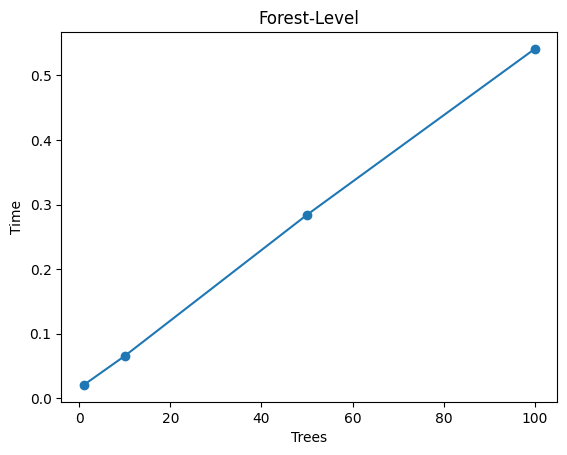

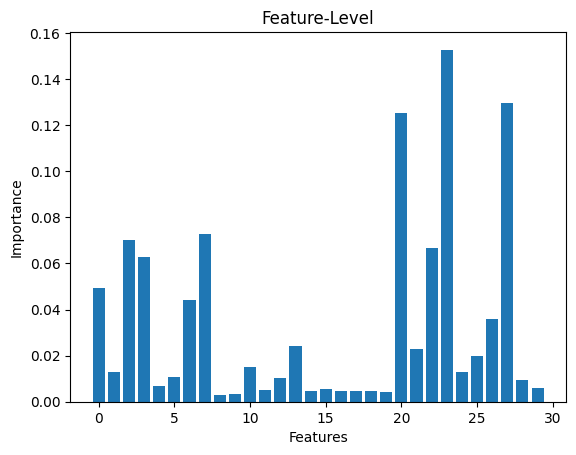

/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


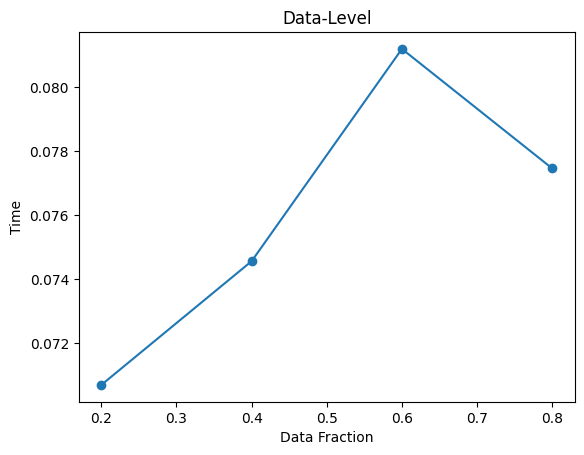

    Metric        CPU       GPU
0    Train  12.740004  0.743181
1  Predict   0.124010  0.546534
2      Acc   1.000000  1.000000


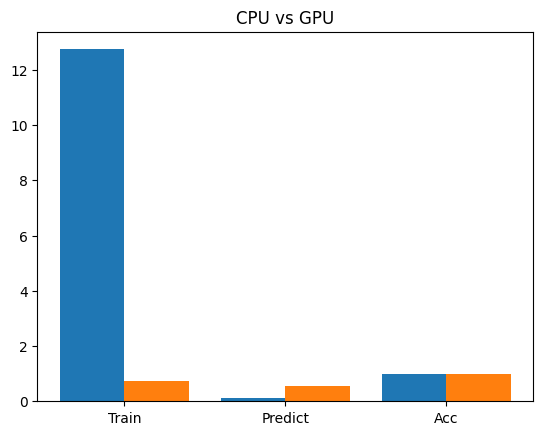

1.0000 1.0000 12.7400 0.7432 17.14


In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier as RF_cpu
from sklearn.metrics import accuracy_score

import cudf
from cuml.ensemble import RandomForestClassifier as RF_gpu
import cupy as cp


d = load_breast_cancer()
A = d.data
B = d.target

A_big = np.tile(A, (300, 1))
B_big = np.tile(B, 300)

A_tr, A_te, B_tr, B_te = train_test_split(
    A_big, B_big, test_size=0.2, random_state=42
)

A_tr_g = cudf.DataFrame(A_tr)
A_te_g = cudf.DataFrame(A_te)
B_tr_g = cudf.Series(B_tr)
B_te_g = cudf.Series(B_te)


m_cpu = RF_cpu(n_estimators=100, random_state=42)

t0 = time.time()
m_cpu.fit(A_tr, B_tr)
t_cpu_tr = time.time() - t0

t0 = time.time()
p_cpu = m_cpu.predict(A_te)
t_cpu_pr = time.time() - t0

acc_cpu = accuracy_score(B_te, p_cpu)


m_gpu = RF_gpu(n_estimators=100, random_state=42)

t0 = time.time()
m_gpu.fit(A_tr_g, B_tr_g)
cp.cuda.Stream.null.synchronize()
t_gpu_tr = time.time() - t0

t0 = time.time()
p_gpu = m_gpu.predict(A_te_g)
cp.cuda.Stream.null.synchronize()
t_gpu_pr = time.time() - t0

p_gpu = p_gpu.to_numpy()
acc_gpu = accuracy_score(B_te, p_gpu)

sp = t_cpu_tr / t_gpu_tr


ts = [1, 10, 50, 100]
tt = []

for v in ts:
    m = RF_gpu(n_estimators=v)
    t0 = time.time()
    m.fit(A_tr_g, B_tr_g)
    cp.cuda.Stream.null.synchronize()
    tt.append(time.time() - t0)

plt.figure()
plt.plot(ts, tt, marker='o')
plt.xlabel("Trees")
plt.ylabel("Time")
plt.title("Forest-Level")
plt.show()


imp = m_cpu.feature_importances_

plt.figure()
plt.bar(range(len(imp)), imp)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature-Level")
plt.show()


fracs = [0.2, 0.4, 0.6, 0.8]
dt = []

for f in fracs:
    n = int(len(A) * f)
    A_s = A[:n]
    B_s = B[:n]

    A_sg = cudf.DataFrame(A_s)
    B_sg = cudf.Series(B_s)

    m = RF_gpu(n_estimators=50)
    t0 = time.time()
    m.fit(A_sg, B_sg)
    cp.cuda.Stream.null.synchronize()
    dt.append(time.time() - t0)

plt.figure()
plt.plot(fracs, dt, marker='o')
plt.xlabel("Data Fraction")
plt.ylabel("Time")
plt.title("Data-Level")
plt.show()


arr_g = cp.array(A_tr)
h, b = cp.histogram(arr_g[:, 0], bins=10)


df = pd.DataFrame({
    "Metric": ["Train", "Predict", "Acc"],
    "CPU": [t_cpu_tr, t_cpu_pr, acc_cpu],
    "GPU": [t_gpu_tr, t_gpu_pr, acc_gpu]
})

print(df)

plt.figure()
x = np.arange(3)

plt.bar(x - 0.2, df["CPU"], width=0.4)
plt.bar(x + 0.2, df["GPU"], width=0.4)

plt.xticks(x, df["Metric"])
plt.title("CPU vs GPU")
plt.show()


print(f"{acc_cpu:.4f} {acc_gpu:.4f} {t_cpu_tr:.4f} {t_gpu_tr:.4f} {sp:.2f}")